In [ ]:
# DBSCAN Clustering (Density-Based Spatial Clustering of Applications with Noise)
"""
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised machine learning algorithm used to group data points based on density. It forms clusters in regions where data points are closely packed and identifies isolated points as noise (outliers).
Unlike K-Means, DBSCAN does not require the number of clusters (K) to be specified in advance.
Key Idea
DBSCAN groups together points that are close to each other and have a sufficient number of neighboring points. Points that do not belong to any dense region are considered noise.

Important Terms
1. Epsilon (ε or Eps)
Epsilon (ε) is the maximum distance within which two points are considered neighbors.
Example:
If ε = 2 units, then all points within 2 units of a point are considered its neighbors.
      ε = 2

        ●
      / | \
     ●  ●  ●
2. MinPts (Minimum Points)
MinPts is the minimum number of neighboring points (including the point itself) required to form a dense region (cluster).
Example:
MinPts = 4
      ●
   ●  ●  ●
      ●
There are 5 points, so this region forms a cluster.

Types of Points in DBSCAN
1. Core Point
A Core Point has at least MinPts neighbors within the ε distance.
Example
      ●
   ●  ●  ●
      ●
If ε includes all these points and MinPts = 5, the center point is a Core Point.

2. Border Point
A Border Point has fewer than MinPts neighbors, but it lies within the ε neighborhood of a Core Point.
Example
Core Point
      ●
   ●  ●  ●
          \
           ○
The point ○ is a Border Point because it is close to the Core Point but does not have enough neighbors to become a Core Point itself.

3. Noise (Outlier) Point
A Noise Point is neither a Core Point nor a Border Point. It does not belong to any cluster.
Example
● ● ● ●
                  ×
The point × is too far from other points, so it is treated as Noise.

Working of DBSCAN Algorithm
Step 1: Choose the values of ε (Epsilon) and MinPts.
Step 2: Select an unvisited point.
Step 3: Find all neighboring points within the ε distance.
Step 4: If the point has at least MinPts neighbors, it becomes a Core Point, and a new cluster is created.
Otherwise, mark it as Noise temporarily.
Step 5: Expand the cluster by adding all density-connected neighboring points.
Step 6: Repeat the process until all points have been visited.
"""

In [ ]:
"""
Example
Suppose we have the following points:

A   B   C

D   E

             F   G

                    H

Assume
ε = 2
MinPts = 3
Step 1
A, B, C, D, E
These points are close together.
Cluster 1
A  B  C
D  E
Step 2
F  G
They have enough nearby points to form another cluster.

Cluster 2
F  G
(If MinPts is satisfied.)

Step 3
H
H is isolated.
Noise
H
Final Result
Cluster 1 : A B C D E
Cluster 2 : F G
Noise : H
"""

In [ ]:
# | Feature                     | K-Means          | Hierarchical Clustering | DBSCAN                |
# | --------------------------- | ---------------- | ----------------------- | --------------------- |
# | Learning Type               | Unsupervised     | Unsupervised            | Unsupervised          |
# | Number of Clusters Required | Yes (K)          | No                      | No                    |
# | Detects Noise               | No               | No                      | Yes                   |
# | Cluster Shape               | Mostly spherical | Tree-based hierarchy    | Arbitrary (any shape) |
# | Handles Outliers            | Poorly           | Poorly                  | Very well             |
# | Main Concept                | Centroid-based   | Distance hierarchy      | Density-based         |
# | Output                      | K clusters       | Dendrogram + clusters   | Clusters + Noise      |


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

In [3]:
from sklearn.datasets import make_moons
x , y = make_moons(n_samples=250,noise=0.05)
df={"data1":x[:,0],"data2":x[:,1]}

In [4]:
dataset = pd.DataFrame(df)
dataset.head(3)

,data1,data2
0,1.871490,0.007363
1,0.283792,-0.198953
2,1.986738,0.437130


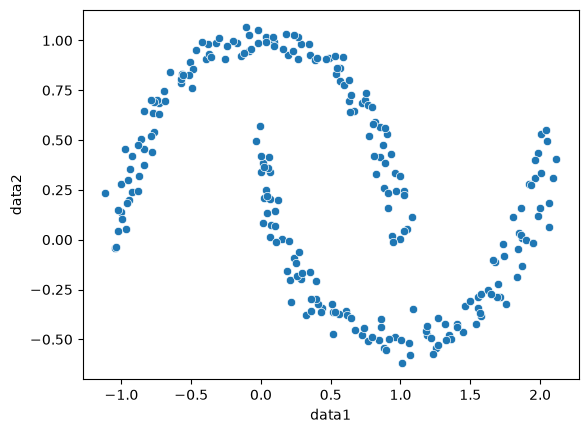

In [5]:
sns.scatterplot(x="data1",y="data2",data=dataset)
plt.show()

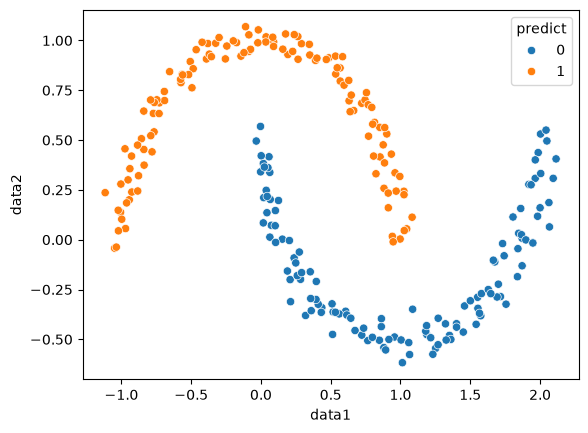

In [7]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.2,min_samples=5)
dataset["predict"] = db.fit_predict(dataset)
sns.scatterplot(x="data1",y="data2",data=dataset, hue="predict")
plt.show()